# Task 1: Data Cleaning & Preprocessing

## Objective
The objective of this task is to clean and prepare raw data for Machine Learning.

## Dataset
Titanic Dataset

## Operations Performed
- Dataset exploration
- Missing value detection and handling
- Categorical variable encoding
- Feature scaling
- Outlier detection using boxplots
- Outlier removal
- Final dataset preparation

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [7]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
missing_values = df.isnull().sum()

print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


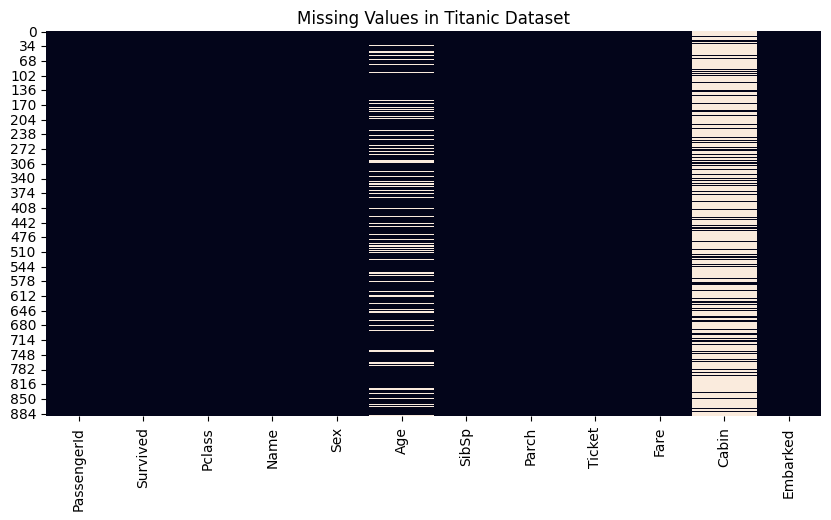

In [12]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Titanic Dataset")
plt.show()

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [14]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [15]:
df = df.drop(columns=["Cabin"])

In [16]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [17]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

In [18]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [19]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [20]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Categorical Encoding

Categorical variables cannot be directly used by most machine learning algorithms in their original text form.

Therefore, categorical features such as Sex and Embarked were converted into numerical features using one-hot encoding.

One-hot encoding creates separate binary columns for different categories.


In [21]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 8)
Target shape: (891,)


In [22]:
numerical_columns = ["Age", "Fare", "SibSp", "Parch", "Pclass"]

In [23]:
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

In [25]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.827377,-0.565736,0.432793,-0.473674,-0.502445,True,False,True
1,-1.566107,0.663861,0.432793,-0.473674,0.786845,False,False,False
2,0.827377,-0.258337,-0.474545,-0.473674,-0.488854,False,False,True
3,-1.566107,0.433312,0.432793,-0.473674,0.420730,False,False,True
4,0.827377,0.433312,-0.474545,-0.473674,-0.486337,True,False,True


## Feature Scaling

Feature scaling brings numerical features to a comparable scale.

Standardization transforms the data approximately so that:
- Mean = 0
- Standard deviation = 1

Standardization is useful when numerical features have very different ranges.

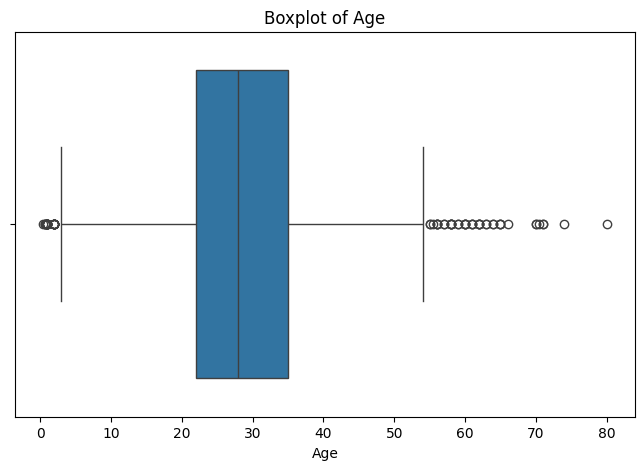

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Age"])

plt.title("Boxplot of Age")
plt.show()

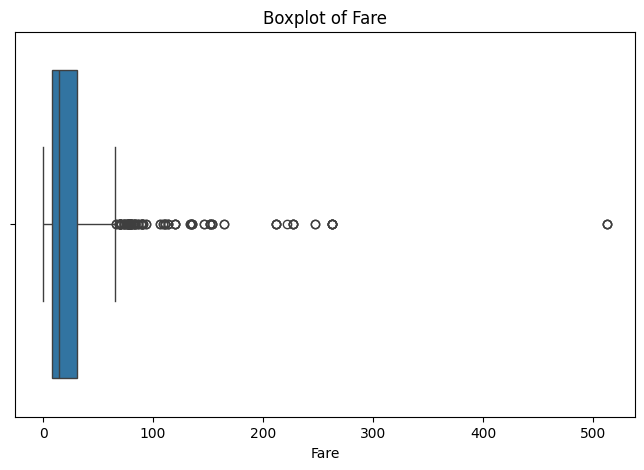

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Fare")
plt.show()

## Outlier Detection Using IQR

The Interquartile Range (IQR) method is used to detect potential outliers.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these boundaries are considered potential outliers.

In [28]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -26.724
Upper Bound: 65.6344


In [29]:
outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Number of Fare outliers:", len(outliers))

Number of Fare outliers: 116


In [30]:
df_clean = df[
    (df["Fare"] >= lower_bound) &
    (df["Fare"] <= upper_bound)
].copy()

In [31]:
print("Original dataset shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original dataset shape: (891, 9)
After outlier removal: (775, 9)


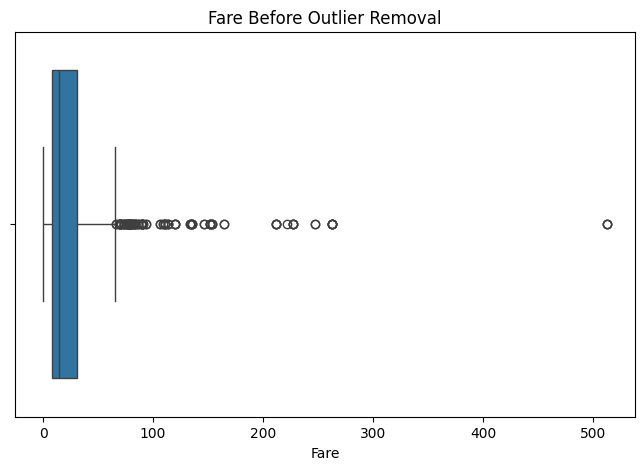

In [35]:
#Visualize before removing outliers
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Before Outlier Removal")
plt.show()

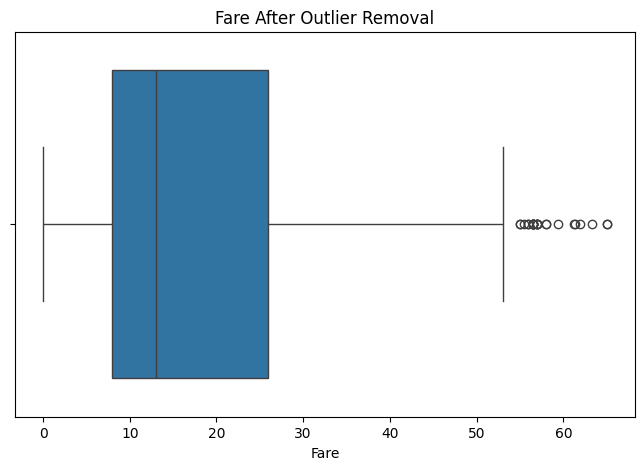

In [36]:
#Visualize after removing outliers
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_clean["Fare"])

plt.title("Fare After Outlier Removal")
plt.show()

In [37]:
print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nFirst 5 rows:")
display(df_clean.head())

Final dataset shape: (775, 9)

Missing values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Data types:
Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

First 5 rows:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
5,0,3,28.0,0,0,8.4583,True,True,False


In [38]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [39]:
from google.colab import files

files.download("titanic_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

In this task, the Titanic dataset was cleaned and prepared for Machine Learning.

The following preprocessing techniques were performed:

1. Explored the dataset structure, data types, and missing values.
2. Handled missing numerical values using median imputation.
3. Handled missing categorical values using mode imputation.
4. Removed the Cabin column because of a large number of missing values.
5. Removed unnecessary columns such as PassengerId, Name, and Ticket.
6. Converted categorical variables into numerical form using one-hot encoding.
7. Standardized numerical features using StandardScaler.
8. Detected potential outliers using boxplots and the IQR method.
9. Removed Fare outliers.
10. Saved the final cleaned dataset.

The resulting dataset is cleaner and more suitable for use in Machine Learning models.